# FWI · Elastic · Marmousi

End-to-end Elastic FWI on Marmousi II. **`vp`, `vs`, and `rho` come straight
from `sweep.datasets`** (Marmousi II ships all three) — we don't derive `vs`
from `vp` via Poisson or `rho` via Gardner anymore.

All three parameters `vp`, `vs`, and `rho` are inverted jointly.

1. load embedded `(vp, vs, rho)` true + smooth models from `sweep.datasets`
2. build geometry, wavelet, and Elastic solver (`impl='c'`)
3. forward-model the observed two-component data (`vx`, `vz`)
4. stochastic Adam: random mini-batch of shots per iter
5. show `vp`, `vs`, `rho` inverted vs. true vs. initial

## Note on amplitudes / Adam `eps`

Elastic `vz` traces with a unit-amplitude Ricker source are ~1e-7. That makes
the MSE loss ~1e-17 and Adam can't escape the `eps` floor. We multiply the
wavelet by `1e6` to push the loss back to O(1) and use `eps=1e-16` to keep
small residual gradients responsive.


## 1. Parameters

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import Elastic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker
from sweep.datasets import load_marmousi, MARMOUSI_DH

dh    = MARMOUSI_DH * 2   # 25 m (12.5 m → 25 m via ::2,::2 downsample)
dt    = 0.0016            # elastic CFL at 25 m
nt    = 2500              # 4.0 s
freq  = 5.0
delay = 0.22
nshots, nrec, batch_shots = 20, 80, 8
src_z, rec_z = 2, 4

lr_vp, lr_vs, lr_rho = 25.0, 15.0, 8.0
n_iter = 30

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## 2. Load the (vp, vs, rho) triplet from sweep.datasets

Marmousi II includes a real shear-wave model (water layer has `vs=0`), so we
no longer fake `vs` from `vp`. `rho` is in kg/m³.

shape: (141, 681)   physical: 3.5 km depth × 17.0 km offset


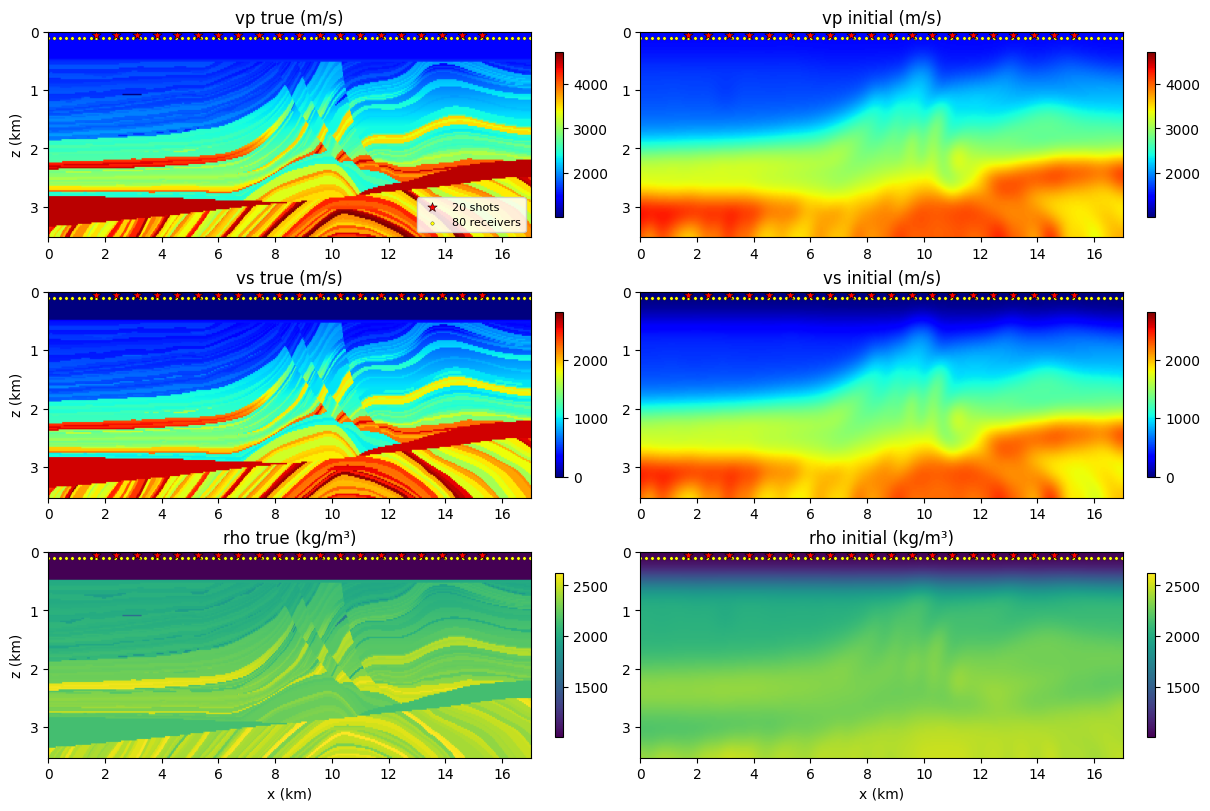

In [2]:
# Full 12.5 m presets, then ::2,::2 downsample to 25 m
vp_true_np  = load_marmousi('vp_true')[::2, ::2].copy()
vs_true_np  = load_marmousi('vs_true')[::2, ::2].copy()
rho_true_np = load_marmousi('rho_true')[::2, ::2].copy()

vp_init_np  = load_marmousi('vp_smooth')[::2, ::2].copy()
vs_init_np  = load_marmousi('vs_smooth')[::2, ::2].copy()
rho_init_np = load_marmousi('rho_smooth')[::2, ::2].copy()

shape = vp_true_np.shape
print('shape:', shape, '  physical:',
      f'{shape[0]*dh/1000:.1f} km depth × {shape[1]*dh/1000:.1f} km offset')

# Acquisition geometry: surface sources + horizontal receiver line
src_x = np.linspace(shape[1] * 0.1, shape[1] * 0.9, nshots).astype(np.int64)
rec_x = np.linspace(0, shape[1] - 1, nrec).astype(np.int64)
src_x_km = src_x * dh / 1000;  src_z_km = src_z * dh / 1000
rec_x_km = rec_x * dh / 1000;  rec_z_km = rec_z * dh / 1000

fig, axes = plt.subplots(3, 2, figsize=(12, 8), constrained_layout=True)
for row, (label, t_arr, i_arr, cmap, unit) in enumerate([
    ('vp',  vp_true_np,  vp_init_np,  'jet',      'm/s'),
    ('vs',  vs_true_np,  vs_init_np,  'jet',      'm/s'),
    ('rho', rho_true_np, rho_init_np, 'viridis',  'kg/m³'),
]):
    vmin = float(min(t_arr.min(), i_arr.min())); vmax = float(max(t_arr.max(), i_arr.max()))
    for col, (arr, suffix) in enumerate([(t_arr, 'true'), (i_arr, 'initial')]):
        ax = axes[row, col]
        im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto',
                       extent=[0, shape[1]*dh/1000, shape[0]*dh/1000, 0])
        ax.scatter(rec_x_km, np.full_like(rec_x_km, rec_z_km, dtype=float),
                   s=6, c='yellow', edgecolors='k', linewidths=0.2)
        ax.scatter(src_x_km, np.full_like(src_x_km, src_z_km, dtype=float),
                   s=50, c='red', marker='*', edgecolors='k', linewidths=0.4)
        ax.set_title(f'{label} {suffix} ({unit})')
        if col == 0: ax.set_ylabel('z (km)')
        if row == 2: ax.set_xlabel('x (km)')
        fig.colorbar(im, ax=ax, shrink=0.8)
# legend on the top-left panel only
axes[0, 0].scatter([], [], s=50, c='red', marker='*', edgecolors='k',
                   linewidths=0.4, label=f'{nshots} shots')
axes[0, 0].scatter([], [], s=6, c='yellow', edgecolors='k', linewidths=0.2,
                   label=f'{nrec} receivers')
axes[0, 0].legend(loc='lower right', fontsize=8, framealpha=0.85)
plt.show()


## 3. Geometry, wavelet, solver

Zero-parameter solver — `pml_type`, `source_type`, `receiver_type`,
`use_ckpt`, `spatial_order`, `abcn`, `free_surface` all default. Elastic's
defaults: `pml_type='cpmls'`, `source_type=['sxx','szz']`,
`receiver_type=['vx','vz']`.

In [3]:
t = np.arange(nt, dtype=np.float32) * dt
wavelet = 1e6 * ricker(t - delay, f=freq)   # rescale (see top-of-notebook note)

sources   = np.stack([src_x, np.full(nshots, src_z, dtype=np.int64)], axis=1)
receivers = np.stack([rec_x, np.full(nrec, rec_z, dtype=np.int64)], axis=1)
receivers = np.repeat(receivers[None, ...], nshots, axis=0)

equation = Elastic(device=device)
solver   = PropTorch(equation, shape=shape, dh=dh, dt=dt, impl='c')
# eager-mode chunk autograd holds activations for a full chunk; shrink the
# stochastic mini-batch when the C path is unavailable so memory stays low.
if solver.impl == 'eager':
    batch_shots = min(batch_shots, 2)
print('impl:', solver.impl, ' batch_shots:', batch_shots)


impl: c  batch_shots: 8


### Aside · which sources and receivers does this equation accept?

`Elastic` publishes a structured field table — query `eq.models` for the
expected model input order, `available_source_fields()` / `available_receiver_fields()`
for valid source / receiver options. See the
[Equations user guide](../../user-guide/equations/) for the full rundown.

In [4]:
print('models (input order matters!):')
for spec in equation.MODEL_SPECS:
    unit = f' [{spec.unit}]' if spec.unit else ''
    print(f'  - {spec.name:8s}{unit}  — {spec.description}')
print('defaults  :', equation.default_source_fields, '/', equation.default_receiver_fields)
print('receivers :')
for spec in equation.available_receiver_fields():
    print(f'  - {spec.name:8s} aliases={spec.aliases}  — {spec.description}')

models (input order matters!):
  - vp       [m/s]  — Elastic P-wave velocity model.
  - vs       [m/s]  — Elastic S-wave velocity model.
  - rho      [kg/m^3]  — Density model.
defaults  : ['sxx', 'szz'] / ['vx', 'vz']
receivers :
  - vx       aliases=('velocity_x',)  — Particle velocity in the x direction.
  - vz       aliases=('velocity_z',)  — Particle velocity in the z direction.
  - sxx      aliases=('stress_xx',)  — Normal stress in the x direction.
  - szz      aliases=('stress_zz',)  — Normal stress in the z direction.


## 4. Forward modeling — observed vz gather

observed shape: (20, 2500, 80, 2)


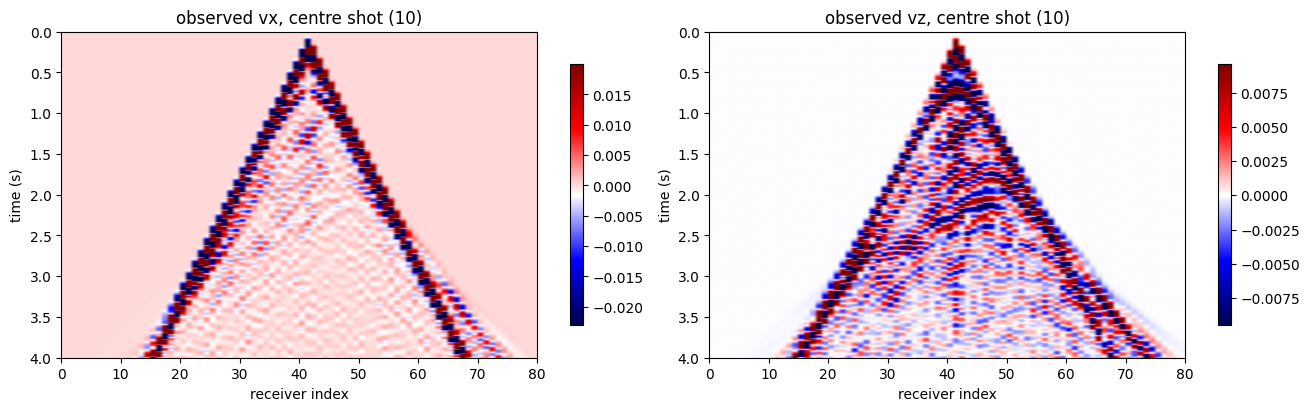

In [5]:
vp_true  = torch.tensor(vp_true_np,  device=device)
vs_true  = torch.tensor(vs_true_np,  device=device)
rho_true = torch.tensor(rho_true_np, device=device)
models_true = [vp_true, vs_true, rho_true]

with torch.no_grad():
    observed = solver(wavelet, sources, receivers, models=models_true).detach()
print('observed shape:', tuple(observed.shape))

centre = nshots // 2
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for ax, comp, name in zip(axes, [0, 1], ['vx', 'vz']):
    gather = observed[centre, :, :, comp].detach().cpu().numpy()
    vmin, vmax = np.percentile(gather, [2, 98])
    im = ax.imshow(gather, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto',
                   extent=[0, nrec, nt * dt, 0])
    ax.set_xlabel('receiver index'); ax.set_ylabel('time (s)')
    ax.set_title(f'observed {name}, centre shot ({centre})')
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()


## 5. Stochastic Adam loop — invert vp and vs (rho fixed)

Each iteration samples a random mini-batch of `batch_shots` shots. `vp` and
`vs` get their own learning rates (`vs` slightly lower); `rho` stays frozen.

In [6]:
import time
rng = np.random.default_rng(0)
t_start = time.time()
vp_var  = torch.tensor(vp_init_np,  device=device, requires_grad=True)
vs_var  = torch.tensor(vs_init_np,  device=device, requires_grad=True)
rho_var = torch.tensor(rho_init_np, device=device, requires_grad=True)

optimizer = torch.optim.Adam([
    {'params': [vp_var],  'lr': lr_vp},
    {'params': [vs_var],  'lr': lr_vs},
    {'params': [rho_var], 'lr': lr_rho},
], eps=1e-16)
losses = []

for it in range(n_iter):
    iter_t0 = time.time()
    idx = rng.choice(nshots, size=batch_shots, replace=False)
    optimizer.zero_grad()
    predicted = solver(wavelet, sources[idx], receivers[idx], models=[vp_var, vs_var, rho_var])
    loss = (predicted - observed[idx]).pow(2).mean()
    loss.backward()
    optimizer.step()
    # Keep vs non-negative (Marmousi II water layer has vs=0); keep rho positive
    with torch.no_grad():
        vs_var.clamp_(min=0.0)
        rho_var.clamp_(min=100.0)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    iter_t = time.time() - iter_t0
    losses.append(float(loss.detach().cpu()))
    print(f'iter {it:02d}  loss {losses[-1]:.4e}  iter={iter_t:.2f}s  total={time.time()-t_start:.1f}s')


iter 00  loss 8.7626e-05  iter=1.74s  total=1.7s


iter 01  loss 6.3319e-05  iter=1.30s  total=3.0s


iter 02  loss 6.2381e-05  iter=1.31s  total=4.4s


iter 03  loss 4.3372e-05  iter=1.30s  total=5.7s


iter 04  loss 3.1742e-05  iter=1.31s  total=7.0s


...

iter 25  loss 1.0757e-05  iter=1.32s  total=34.5s


iter 26  loss 8.5627e-06  iter=1.32s  total=35.9s


iter 27  loss 8.8318e-06  iter=1.31s  total=37.2s


iter 28  loss 7.1213e-06  iter=1.32s  total=38.5s


iter 29  loss 7.5167e-06  iter=1.32s  total=39.8s


## 6. Results

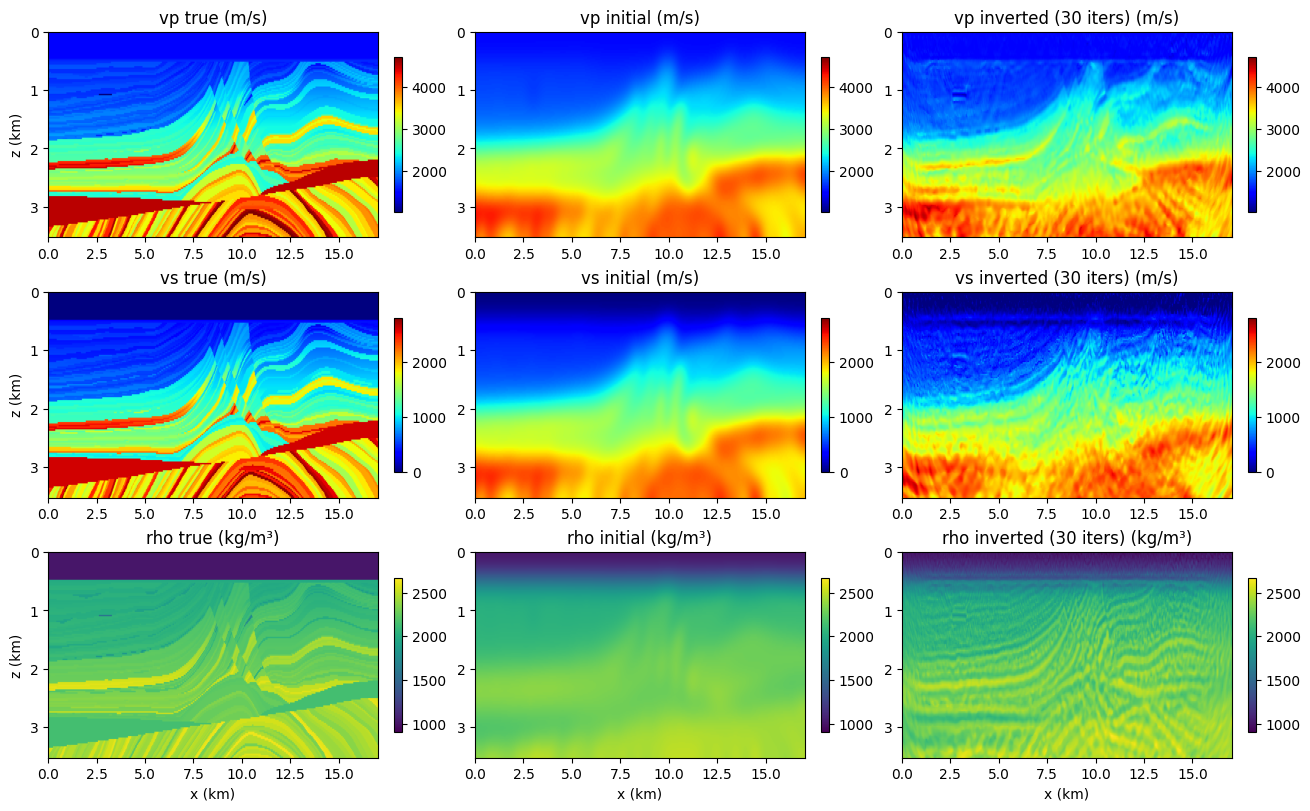

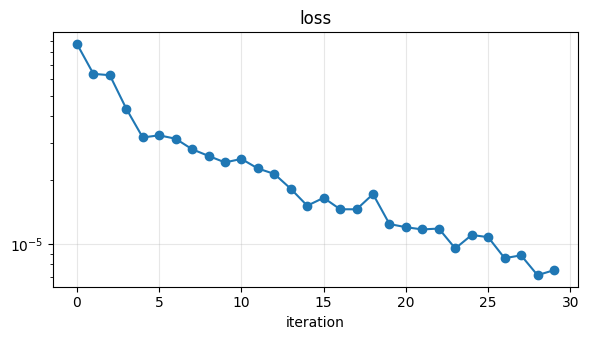

In [7]:
vp_final  = vp_var.detach().cpu().numpy()
vs_final  = vs_var.detach().cpu().numpy()
rho_final = rho_var.detach().cpu().numpy()

fig, axes = plt.subplots(3, 3, figsize=(13, 8), constrained_layout=True)
for row, (label, t_arr, i_arr, f_arr, cmap, unit) in enumerate([
    ('vp',  vp_true_np,  vp_init_np,  vp_final,  'jet',     'm/s'),
    ('vs',  vs_true_np,  vs_init_np,  vs_final,  'jet',     'm/s'),
    ('rho', rho_true_np, rho_init_np, rho_final, 'viridis', 'kg/m³'),
]):
    vmin = float(min(t_arr.min(), i_arr.min(), f_arr.min()))
    vmax = float(max(t_arr.max(), i_arr.max(), f_arr.max()))
    for col, (arr, title) in enumerate([
        (t_arr, f'{label} true'),
        (i_arr, f'{label} initial'),
        (f_arr, f'{label} inverted ({n_iter} iters)'),
    ]):
        im = axes[row, col].imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto',
                                   extent=[0, shape[1]*dh/1000, shape[0]*dh/1000, 0])
        axes[row, col].set_title(f'{title} ({unit})')
        if col == 0: axes[row, col].set_ylabel('z (km)')
        if row == 2: axes[row, col].set_xlabel('x (km)')
        fig.colorbar(im, ax=axes[row, col], shrink=0.75)
plt.show()

plt.figure(figsize=(6, 3.5))
plt.plot(losses, marker='o')
plt.title('loss'); plt.xlabel('iteration')
plt.yscale('log'); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

---

<p><strong>Download this notebook</strong> &mdash; <a href="02_fwi_elastic_marmousi.ipynb" download><code>02_fwi_elastic_marmousi.ipynb</code></a> &middot; or <a href="https://github.com/DeepWave-KAUST/sweep/blob/dev/examples/notebooks/02_fwi_elastic_marmousi.ipynb">view on GitHub</a></p>